In [32]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images
using Statistics

In [33]:
function load_crop_imgs(filenames, pathdir, x_crop, y_crop)
    imgs_atoms, imgs_bkg, imgs_dark = [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"])), x_crop, y_crop)
            img_bkg = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"])), x_crop, y_crop)
            img_dark = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"])), x_crop, y_crop)
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark)
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark
end

function crop_img(img, x_crop, y_crop)
    return img[y_crop, x_crop]
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, sat, t_exp)
    ODs = zeros(size(imgs_atoms))
    for i in 1:size(imgs_atoms)[1]
        for j = 1:size(imgs_atoms)[2]
            OD = (imgs_atoms[i, j, :, :] .- imgs_dark[i, j, :, :]) ./ (imgs_bkg[i, j, :, :] .- imgs_dark[i, j, :, :])

            OD[OD .<= 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
            OD .= -log10.(OD)
            OD[isnan.(OD)] .= 0 # Map Nan values to 0

            # For high intensity, modified OD formula
            if sat[i] >= 1
                OD .+= (imgs_bkg[i, j, :, :] .- imgs_atoms[i, j, :, :]) / (7000*t_exp[i]/5e-6)
            end
            ODs[i, j, :, :] .= OD
        end
    end
    return ODs
end

compute_OD_high_low_intensity (generic function with 1 method)

In [ ]:
pathdir = "Y:/TwoDGas/2025/07/04"
dir_names_datasets = readdir(pathdir)
dir_names_datasets = dir_names_datasets[dir_names_datasets .!= ".DS_Store"]
dir_names_datasets = dir_names_datasets[10:end]
Sat = [0.5, 1, 5, 32, 56, 65] # Estimated saturation parameter
τ_exp = [8, 7, 6, 5, 3, 2].*1e-6 # In s
x_crop = [1130:1730;]
y_crop = [1670:2370;];

### Load and crop the images

In [2]:
if !isdir("Saved_exp_data")
    mkdir("Saved_exp_data")
end

"Saved_exp_data"

In [36]:
Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds = zeros((length(Sat), length(readdir(pathdir*"/"*dir_names_datasets[1])), length(y_crop), length(x_crop))), zeros((length(Sat), length(readdir(pathdir*"/"*dir_names_datasets[1])), length(y_crop), length(x_crop))), zeros((length(Sat), length(readdir(pathdir*"/"*dir_names_datasets[1])), length(y_crop), length(x_crop)));

In [37]:
for (i, dir_name_ds) in ProgressBar(enumerate(dir_names_datasets))
    files_path = readdir(pathdir*"/"*dir_name_ds)
        atoms, bkg, dark = load_crop_imgs(
        files_path,
        pathdir * "/" * dir_name_ds * "/",
        x_crop,
        y_crop)
    for j in 1:length(atoms)
        Imgs_atoms_crop_ds[i, j, :, :] .= atoms[j]
        Imgs_bkg_crop_ds[i, j, :, :]   .= bkg[j]
        Imgs_dark_crop_ds[i, j, :, :]  .= dark[j]
    end
end

0.0%┣                                                ┫ 0/6 [00:00<00:00, -0s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:42<Inf:Inf, InfGs/it]
33.3%┣███████████████▍                              ┫ 2/6 [01:44<06:56, 104s/it]
50.0%┣███████████████████████▌                       ┫ 3/6 [02:44<04:06, 82s/it]
66.7%┣███████████████████████████████▍               ┫ 4/6 [04:02<02:41, 81s/it]
83.3%┣███████████████████████████████████████▏       ┫ 5/6 [04:46<01:12, 72s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [05:33<00:00, 67s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [05:33<00:00, 67s/it]


In [38]:
@save "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds

### Compute the ODs

In [39]:
ODs_dataset = compute_OD_high_low_intensity(Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds, Sat, τ_exp);

In [40]:
@save "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset

### Plot to check

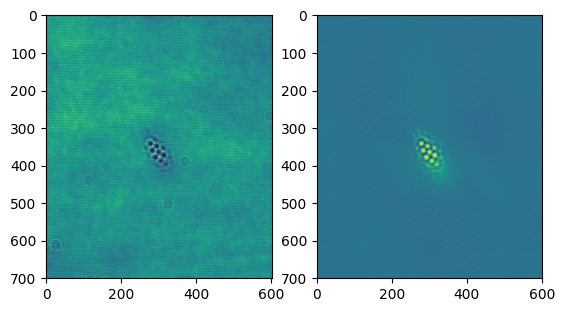

false

In [41]:
i, j = 6, 5

close("all")
fig, axs = subplots(1, 2)
axs[1].imshow(Imgs_atoms_crop_ds[i, j, :, :])
axs[2].imshow(ODs_dataset[i, j, :, :])
pygui(false)

# Save the ODs and negative ODs

In [5]:
if !isdir("Images")
    mkdir("Images")
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_"))
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_"))
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs")
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs")
end

"Images/2025_07_04/Negative_ODs"

In [43]:
size(ODs_dataset)[2]

50

In [44]:
close("all")
fig, axs = subplots()

for i in ProgressBar(1:size(ODs_dataset)[1])
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])")
    end
    for j = 1:size(ODs_dataset)[2]
        img = axs.imshow(ODs_dataset[i, j, :, :], cmap="plasma") #, aspect="auto"
        cb = colorbar(img)
        savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

0.0%┣                                                ┫ 0/6 [00:00<00:00, -0s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:11<Inf:Inf, InfGs/it]
33.3%┣███████████████▊                               ┫ 2/6 [00:21<01:23, 21s/it]
50.0%┣███████████████████████▌                       ┫ 3/6 [00:31<00:46, 15s/it]
66.7%┣███████████████████████████████▍               ┫ 4/6 [00:41<00:27, 14s/it]
83.3%┣███████████████████████████████████████▏       ┫ 5/6 [00:51<00:13, 13s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [01:01<00:00, 12s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [01:01<00:00, 12s/it]


In [45]:
close("all")
fig, axs = subplots()

for i in ProgressBar(1:size(ODs_dataset)[1])
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])")
    end
    for j = 1:size(ODs_dataset)[2]
        img = axs.imshow(ODs_dataset[i, j, :, :], cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
        cb = colorbar(img)
        savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

0.0%┣                                                ┫ 0/6 [00:00<00:00, -0s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:11<Inf:Inf, InfGs/it]
33.3%┣███████████████▊                               ┫ 2/6 [00:22<01:29, 22s/it]
50.0%┣███████████████████████▌                       ┫ 3/6 [00:35<00:53, 18s/it]
66.7%┣███████████████████████████████▍               ┫ 4/6 [00:48<00:32, 16s/it]
83.3%┣███████████████████████████████████████▏       ┫ 5/6 [00:59<00:15, 15s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [01:10<00:00, 14s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [01:10<00:00, 14s/it]
